# Import The Libraries

In [1]:
import pandas as pd

# Loading the Dataset

In [2]:
df=pd.read_csv('titanic.csv')

# Understand the data 

In [3]:
df.columns   #google and check the meaning of the column names
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


# Observation
1.No duplicates

2.null values present 
 
        1.age:float-> (mean)

        2.fare:float-> (mean)

        3.cabin:object-> (remove the column as it is not important for stating wheter the passenger survied or not)
  
        4.embarked:object->(mode)

3.No invalid datatype

# Data Cleaning

In [4]:
df.duplicated().any()

False

In [5]:
age_mean=df['age'].mean()
fare_mean=df['fare'].mean()
emb_mode=df['embarked'].mode()[0]
df['age']=df['age'].fillna(age_mean)   #replacing null values with mean
df['fare']=df['fare'].fillna(fare_mean)  #replacing null values with mean
df['embarked']=df['embarked'].fillna(emb_mode)  #replacing null values with mode
df=df.drop(columns=['cabin'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   object 
 9   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 102.4+ KB


# Data Transformation / Feature Engineering


In [6]:
df['age']=df['age'].round(1)   #reducing the decimal points to 1
df['fare']=df['fare'].round(1)

In [7]:
#combining 2 diff columns into 1
df['family_cnt']=df['sibsp']+df['parch']
df=df.drop(columns=['sibsp','parch'])
df

,pclass,name,sex,age,ticket,fare,embarked,survived,family_cnt
0,1,"Allen, Miss. Elisabeth Walton",female,29.0,24160,211.3,S,1,0
1,1,"Allison, Master. Hudson Trevor",male,0.9,113781,151.6,S,1,3
2,1,"Allison, Miss. Helen Loraine",female,2.0,113781,151.6,S,0,3
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,113781,151.6,S,0,3
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,113781,151.6,S,0,3
...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5,2665,14.5,C,0,1
1305,3,"Zabour, Miss. Thamine",female,29.9,2665,14.5,C,0,1
1306,3,"Zakarian, Mr. Mapriededer",male,26.5,2656,7.2,C,0,0
1307,3,"Zakarian, Mr. Ortin",male,27.0,2670,7.2,C,0,0


In [8]:
#in embarked column what unique values are there and replacing them with their fullforms
df['embarked'].unique()
#C = Cherbourg, Q = Queenstown, S = Southampton
df['embarked']=df['embarked'].replace({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'})

In [9]:
#Rename
df=df.rename(columns={'sex':'gender',})


In [10]:
#title case that is first letter capital and remaining lower case
df['gender']=df['gender'].str.title()


In [11]:
df

,pclass,name,gender,age,ticket,fare,embarked,survived,family_cnt
0,1,"Allen, Miss. Elisabeth Walton",Female,29.0,24160,211.3,Southampton,1,0
1,1,"Allison, Master. Hudson Trevor",Male,0.9,113781,151.6,Southampton,1,3
2,1,"Allison, Miss. Helen Loraine",Female,2.0,113781,151.6,Southampton,0,3
3,1,"Allison, Mr. Hudson Joshua Creighton",Male,30.0,113781,151.6,Southampton,0,3
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",Female,25.0,113781,151.6,Southampton,0,3
...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",Female,14.5,2665,14.5,Cherbourg,0,1
1305,3,"Zabour, Miss. Thamine",Female,29.9,2665,14.5,Cherbourg,0,1
1306,3,"Zakarian, Mr. Mapriededer",Male,26.5,2656,7.2,Cherbourg,0,0
1307,3,"Zakarian, Mr. Ortin",Male,27.0,2670,7.2,Cherbourg,0,0


In [12]:
#splitting name into 3 parts
df['Last_name']=df['name'].str.split(',',expand=True)[0]
temp=df['name'].str.split(',',expand=True)[1]
df[['Title','First_Name']]=temp.str.split('.',n=1,expand=True)
df=df.drop(columns=['name'])
df


,pclass,gender,age,ticket,fare,embarked,survived,family_cnt,Last_name,Title,First_Name
0,1,Female,29.0,24160,211.3,Southampton,1,0,Allen,Miss,Elisabeth Walton
1,1,Male,0.9,113781,151.6,Southampton,1,3,Allison,Master,Hudson Trevor
2,1,Female,2.0,113781,151.6,Southampton,0,3,Allison,Miss,Helen Loraine
3,1,Male,30.0,113781,151.6,Southampton,0,3,Allison,Mr,Hudson Joshua Creighton
4,1,Female,25.0,113781,151.6,Southampton,0,3,Allison,Mrs,Hudson J C (Bessie Waldo Daniels)
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5,2665,14.5,Cherbourg,0,1,Zabour,Miss,Hileni
1305,3,Female,29.9,2665,14.5,Cherbourg,0,1,Zabour,Miss,Thamine
1306,3,Male,26.5,2656,7.2,Cherbourg,0,0,Zakarian,Mr,Mapriededer
1307,3,Male,27.0,2670,7.2,Cherbourg,0,0,Zakarian,Mr,Ortin


In [13]:
#creating a new col based on some condition
g=df['ticket'].value_counts()
solo_ticket=g[g==1].index
def f1(d):
    if d['family_cnt']>0 :
        return 'Family'
    else:
        if d['ticket'] in (solo_ticket):
            return 'solo'
        else:
         return "Friends"

In [14]:
df['Companion_type']=df.apply(f1,axis=1)


In [15]:
df.columns

Index(['pclass', 'gender', 'age', 'ticket', 'fare', 'embarked', 'survived',
       'family_cnt', 'Last_name', 'Title', 'First_Name', 'Companion_type'],
      dtype='object')

In [16]:
#shuffling the columns acc to the need
lst=['ticket','Title','First_Name','Last_name', 'gender','age','Companion_type','family_cnt','pclass','embarked', 'fare','survived']
df=df[lst]
df


,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1
2,113781,Miss,Helen Loraine,Allison,Female,2.0,Family,3,1,Southampton,151.6,0
3,113781,Mr,Hudson Joshua Creighton,Allison,Male,30.0,Family,3,1,Southampton,151.6,0
4,113781,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,Female,25.0,Family,3,1,Southampton,151.6,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,2665,Miss,Hileni,Zabour,Female,14.5,Family,1,3,Cherbourg,14.5,0
1305,2665,Miss,Thamine,Zabour,Female,29.9,Family,1,3,Cherbourg,14.5,0
1306,2656,Mr,Mapriededer,Zakarian,Male,26.5,solo,0,3,Cherbourg,7.2,0
1307,2670,Mr,Ortin,Zakarian,Male,27.0,solo,0,3,Cherbourg,7.2,0


In [17]:
df['age_cat']=pd.cut(df['age'],bins=[0,15,25,60,81],labels=['child','teen','adult','senior'])


C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\860454754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_cat']=pd.cut(df['age'],bins=[0,15,25,60,81],labels=['child','teen','adult','senior'])


# Data Analysis

1.get all the passenger details

In [18]:
df

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1,adult
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
2,113781,Miss,Helen Loraine,Allison,Female,2.0,Family,3,1,Southampton,151.6,0,child
3,113781,Mr,Hudson Joshua Creighton,Allison,Male,30.0,Family,3,1,Southampton,151.6,0,adult
4,113781,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,Female,25.0,Family,3,1,Southampton,151.6,0,teen
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,2665,Miss,Hileni,Zabour,Female,14.5,Family,1,3,Cherbourg,14.5,0,child
1305,2665,Miss,Thamine,Zabour,Female,29.9,Family,1,3,Cherbourg,14.5,0,adult
1306,2656,Mr,Mapriededer,Zakarian,Male,26.5,solo,0,3,Cherbourg,7.2,0,adult
1307,2670,Mr,Ortin,Zakarian,Male,27.0,solo,0,3,Cherbourg,7.2,0,adult


2. get the names of all the passengers (full name)

In [19]:
df['First_Name']+df['Last_name']

0                           Elisabeth WaltonAllen
1                            Hudson TrevorAllison
2                            Helen LoraineAllison
3                  Hudson Joshua CreightonAllison
4        Hudson J C (Bessie Waldo Daniels)Allison
                          ...                    
1304                                 HileniZabour
1305                                ThamineZabour
1306                          MapriedederZakarian
1307                                OrtinZakarian
1308                                 LeoZimmerman
Length: 1309, dtype: object

3.get all the passengers name,age and gender

In [20]:
lst=['First_Name','age','gender']
df[lst]


,First_Name,age,gender
0,Elisabeth Walton,29.0,Female
1,Hudson Trevor,0.9,Male
2,Helen Loraine,2.0,Female
3,Hudson Joshua Creighton,30.0,Male
4,Hudson J C (Bessie Waldo Daniels),25.0,Female
...,...,...,...
1304,Hileni,14.5,Female
1305,Thamine,29.9,Female
1306,Mapriededer,26.5,Male
1307,Ortin,27.0,Male


4.get male passenger

In [21]:
df.query("gender=='Male'")
#or
df.loc[df['gender']=='Male',]

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
3,113781,Mr,Hudson Joshua Creighton,Allison,Male,30.0,Family,3,1,Southampton,151.6,0,adult
5,19952,Mr,Harry,Anderson,Male,48.0,solo,0,1,Southampton,26.6,1,adult
7,112050,Mr,Thomas Jr,Andrews,Male,39.0,solo,0,1,Southampton,0.0,0,adult
9,PC 17609,Mr,Ramon,Artagaveytia,Male,71.0,solo,0,1,Cherbourg,49.5,0,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1302,2647,Mr,Wazli,Yousif,Male,29.9,solo,0,3,Cherbourg,7.2,0,adult
1303,2627,Mr,Gerious,Yousseff,Male,29.9,Friends,0,3,Cherbourg,14.5,0,adult
1306,2656,Mr,Mapriededer,Zakarian,Male,26.5,solo,0,3,Cherbourg,7.2,0,adult
1307,2670,Mr,Ortin,Zakarian,Male,27.0,solo,0,3,Cherbourg,7.2,0,adult


5.get female passenger name and passenger class

In [22]:
df.loc[df['gender']=='Female',['First_Name','pclass']]
#or
df.query("gender == 'Female' ")[['First_Name','pclass']]

,First_Name,pclass
0,Elisabeth Walton,1
2,Helen Loraine,1
4,Hudson J C (Bessie Waldo Daniels),1
6,Kornelia Theodosia,1
8,Edward Dale (Charlotte Lamson),1
...,...,...
1286,George Joseph (Shawneene Abi-Saab),3
1290,James (Ellen Needs),3
1300,Antoni (Selini Alexander),3
1304,Hileni,3


6.Get the male passenger detials who are travelling in pclass 1

In [23]:
df.query("gender =='Male' and pclass==1")
#or
df.loc[(df["gender"]=='Male')&(df["pclass"]==1),]

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
3,113781,Mr,Hudson Joshua Creighton,Allison,Male,30.0,Family,3,1,Southampton,151.6,0,adult
5,19952,Mr,Harry,Anderson,Male,48.0,solo,0,1,Southampton,26.6,1,adult
7,112050,Mr,Thomas Jr,Andrews,Male,39.0,solo,0,1,Southampton,0.0,0,adult
9,PC 17609,Mr,Ramon,Artagaveytia,Male,71.0,solo,0,1,Cherbourg,49.5,0,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,PC 17597,Mr,Charles Duane,Williams,Male,51.0,Family,1,1,Cherbourg,61.4,0,adult
317,PC 17597,Mr,Richard Norris II,Williams,Male,21.0,Family,1,1,Cherbourg,61.4,1,teen
318,113510,Mr,Fletcher Fellows,Williams-Lambert,Male,29.9,solo,0,1,Southampton,35.0,0,adult
320,19947,Mr,Hugh,Woolner,Male,29.9,solo,0,1,Southampton,35.5,1,adult


7.get the female passengers details who are travleiing in pclass 1 or 3


In [24]:
df.query("gender=='Female'and (pclass==1 or pclass==3)")
#or
df.loc[(df['gender']=='Female')&((df['pclass']==1)|(df['pclass']==3)),]
#or
df.loc[(df['gender']=='Female')&(df['pclass'].isin([1,3])),]

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1,adult
2,113781,Miss,Helen Loraine,Allison,Female,2.0,Family,3,1,Southampton,151.6,0,child
4,113781,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,Female,25.0,Family,3,1,Southampton,151.6,0,teen
6,13502,Miss,Kornelia Theodosia,Andrews,Female,63.0,Family,1,1,Southampton,78.0,1,senior
8,11769,Mrs,Edward Dale (Charlotte Lamson),Appleton,Female,53.0,Family,2,1,Southampton,51.5,1,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1286,2688,Mrs,George Joseph (Shawneene Abi-Saab),Whabee,Female,38.0,solo,0,3,Cherbourg,7.2,1,adult
1290,363272,Mrs,James (Ellen Needs),Wilkes,Female,47.0,Family,1,3,Southampton,7.0,1,adult
1300,2659,Mrs,Antoni (Selini Alexander),Yasbeck,Female,15.0,Family,1,3,Cherbourg,14.5,1,child
1304,2665,Miss,Hileni,Zabour,Female,14.5,Family,1,3,Cherbourg,14.5,0,child


8.get the no.of passengers


In [25]:
df.shape[0]
#or
df['First_Name'].count()

1309

9.get the count the male passengers

In [26]:
df.query('gender=="Male"').shape[0]
#or
df.query('gender=="Male"')['First_Name'].count()
#or
df.loc[df['gender']=='Male',['First_Name']].count()
#or
df.loc[df['gender']=='Male'].shape[0]



843

9.get the average fare amount of all the passenger

In [27]:
round(df['fare'].mean(),3)

33.298

10.get the total fare amount of survived passengers

In [28]:
df.query("survived==1")['fare'].sum()
#or
df.loc[df["survived"]==1,['fare']].sum()


fare    24681.9
dtype: float64

11.find the lowest and highest age among all the passenger

In [29]:
df['age'].min()
df['age'].max()


#or
df.agg({"age":['max','min']})

,age
max,80.0
min,0.2


12.get the total and the higest fare along with the average age


In [30]:
df.agg({'fare':['sum','max'],'age':'mean'})

,fare,age
sum,43586.7,NaN
max,512.3,NaN
mean,NaN,29.88495


13.gender wise no_of_passengers

In [31]:
df.groupby(['gender'])['gender'].count()
#or
df.groupby(['gender']).agg({'gender':'count'})
#or
df['gender'].value_counts()

gender
Male      843
Female    466
Name: count, dtype: int64

groupby()---->grouped_object  1.we can perform aggregation
                              2. get_groups()-->groups


groupby() + count() if we have this combo then we can directly go for value_counts()

after groupping we get 2 things one is index and other one is values

14.get the ticket wise no.of passengers

In [32]:
df.groupby(['ticket'])['ticket'].count()
#or
df['ticket'].value_counts().sort_index()  #sorts acc to index in asc order
df['ticket'].value_counts().sort_values()  #sorts acc to values in asc order

ticket
330980          1
235509          1
237735          1
SC/A.3 2861     1
28228           1
               ..
347077          7
PC 17608        7
CA 2144         8
1601            8
CA. 2343       11
Name: count, Length: 929, dtype: int64

15.get the passenger details only if their ticket is CA2144

In [33]:
df.query("ticket=='1601'")

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
674,1601,Mr,Lee,Bing,Male,32.0,Friends,0,3,Southampton,56.5,1,adult
714,1601,Mr,Chang,Chip,Male,32.0,Friends,0,3,Southampton,56.5,1,adult
805,1601,Mr,Choong,Foo,Male,29.9,Friends,0,3,Southampton,56.5,1,adult
858,1601,Mr,Ling,Hee,Male,29.9,Friends,0,3,Southampton,56.5,1,adult
945,1601,Mr,Ali,Lam,Male,29.9,Friends,0,3,Southampton,56.5,1,adult
946,1601,Mr,Len,Lam,Male,29.9,Friends,0,3,Southampton,56.5,0,adult
949,1601,Mr,Fang,Lang,Male,26.0,Friends,0,3,Southampton,56.5,1,adult
972,1601,Mr,Lee,Ling,Male,28.0,Friends,0,3,Southampton,56.5,0,adult


16.get the ticket value only if count is one
or
get the ticket where the occurenece is 1

In [34]:
g=df['ticket'].value_counts()
g[g==1].index

Index(['345767', '2620', '347069', '376563', '2628', '347065', '350406',
       '36865', '349236', '359309',
       ...
       '7546', '3474', 'SOTON/O2 3101287', 'SOTON/O.Q. 3101311',
       'SOTON/O.Q. 3101312', '373450', '2223', '350046', '3101281', '315082'],
      dtype='object', name='ticket', length=713)

17.Get gender wise total fare 

In [35]:
df.groupby(['gender'])['fare'].sum()

gender
Female    21531.2
Male      22055.5
Name: fare, dtype: float64

18. find the gender with higest fare

In [36]:
df.groupby(['gender'])['fare'].sum().idxmax()


'Male'

19.find the gender with lowest fare

In [37]:
df.groupby(['gender'])['fare'].sum().idxmin()

'Female'

melt() convert the col into rows

# Task

# Level 1

1. get the unique values for (gender,pclass,age_category,companion_type,embarked)

In [38]:
print(df['gender'].unique())
print(df['pclass'].unique())
print(df['age_cat'].unique())
print(df['Companion_type'].unique())
print(df['embarked'].unique())

['Female' 'Male']
[1 2 3]
['adult', 'child', 'teen', 'senior']
Categories (4, object): ['child' < 'teen' < 'adult' < 'senior']
['Friends' 'Family' 'solo']
['Southampton' 'Cherbourg' 'Queenstown']


2. (i)  get the passenger 'Emil' details

   (ii) get the passenger 'Emil' gender,age,companion_type,survival_status

4. get the passenger details who got survived

In [39]:
df.query("survived==1")

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1,adult
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
5,19952,Mr,Harry,Anderson,Male,48.0,solo,0,1,Southampton,26.6,1,adult
6,13502,Miss,Kornelia Theodosia,Andrews,Female,63.0,Family,1,1,Southampton,78.0,1,senior
8,11769,Mrs,Edward Dale (Charlotte Lamson),Appleton,Female,53.0,Family,2,1,Southampton,51.5,1,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,4134,Mrs,(Hedwig),Turkula,Female,63.0,solo,0,3,Southampton,9.6,1,senior
1277,2658,Mr,David,Vartanian,Male,22.0,solo,0,3,Cherbourg,7.2,1,teen
1286,2688,Mrs,George Joseph (Shawneene Abi-Saab),Whabee,Female,38.0,solo,0,3,Cherbourg,7.2,1,adult
1290,363272,Mrs,James (Ellen Needs),Wilkes,Female,47.0,Family,1,3,Southampton,7.0,1,adult


5. get the passenger name,age_category,gender who din't get survive

In [40]:
df.loc[df['survived']==0,['First_Name','gender','age_cat']]

,First_Name,gender,age_cat
2,Helen Loraine,Female,child
3,Hudson Joshua Creighton,Male,adult
4,Hudson J C (Bessie Waldo Daniels),Female,teen
7,Thomas Jr,Male,adult
9,Ramon,Male,senior
...,...,...,...
1304,Hileni,Female,child
1305,Thamine,Female,adult
1306,Mapriededer,Male,adult
1307,Ortin,Male,adult


6. get the top 10 male passengers name in descending order of age

In [41]:
top_10_males=df[df['gender']=="Male"].sort_values(by='age',ascending=False).head(10)
result=top_10_males[['First_Name',"age"]]
result

,First_Name,age
14,Algernon Henry Wilson,80.0
1235,Johan,74.0
9,Ramon,71.0
135,George B,71.0
727,Patrick,70.5
506,Henry Michael,70.0
81,Edward Gifford,70.0
285,Isidor,67.0
594,Edward H,66.0
782,Frank,65.0


7. find the average age of passengers

In [42]:
df['age'].mean()

29.884950343773873

8. find the average age of female passengers


In [43]:
df.query("gender=='Female'")['age'].mean()

28.890343347639483

9. find the average age of male passengers

In [44]:
df.query("gender=='Male'")['age'].mean()

30.434756820877816

10. find the survival  rate of passengers


In [45]:
df['survived'].mean()*100

38.19709702062643

11. find the survival  rate of female passengers

In [46]:
df.query("gender=='Female'")['survived'].mean()*100

72.74678111587983

12. find the survival  rate of male passengers

In [47]:
df.query("gender=='Male'")['survived'].mean()*100

19.098457888493474

12. get highest and lowest age of passengers

In [48]:
df.agg({'age':['min','max']})

,age
min,0.2
max,80.0


13. get the highest and lowest fare amount

In [49]:
df.agg({'fare':['min','max']})

,fare
min,0.0
max,512.3


14. get the male passengers average fare 

In [50]:
df.query("gender=='Male'")['fare'].mean()

26.163107947805457

15. get the female passengers average fare 

In [51]:
df.query("gender=='Female'")['fare'].mean()

46.204291845493564

16. how many solo travellers are travelling

In [52]:
df.query("Companion_type=='solo'").count()[0]

C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\2498301063.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.query("Companion_type=='solo'").count()[0]


663

17. how many  travellers are travelling with friends

In [53]:
df.query("Companion_type=='Friends'").count()[0]

C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\1339582379.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.query("Companion_type=='Friends'").count()[0]


127

18. how many  travellers are travelling with family

In [54]:
df.query("Companion_type=='Family'").count()[0]

C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\695682911.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.query("Companion_type=='Family'").count()[0]


519

19. get the count of passengers name,gender,age,pclass who are paying highest fare amount

In [55]:
max_fare=df['fare'].max()
a=df.loc[df['fare']==max_fare,['age','gender','fare','First_Name']]
count=len(a)
print(count)
print(a)


4
      age  gender   fare                                         First_Name
49   36.0    Male  512.3                              Thomas Drake Martinez
50   58.0  Female  512.3   James Warburton Martinez (Charlotte Wardle Dr...
183  35.0    Male  512.3                                          Gustave J
302  35.0  Female  512.3                                               Anna


19. get the count of passengers name,gender,age,pclass who are paying lowest fare amount

In [56]:
min_fare=df['fare'].min()
a=df.loc[df['fare']==min_fare,['age','gender','fare','First_Name']]
count=len(a)
print(count)
print(a)

17
       age gender  fare                First_Name
7     39.0   Male   0.0                 Thomas Jr
70    29.9   Male   0.0   Roderick Robert Crispin
125   29.9   Male   0.0                   Richard
150   40.0   Male   0.0                   William
170   49.0   Male   0.0              Joseph Bruce
223   29.9   Male   0.0       William Henry Marsh
234   38.0   Male   0.0               John George
363   29.9   Male   0.0                   William
384   29.9   Male   0.0            Alfred Fleming
410   29.9   Male   0.0     Anthony Wood "Archie"
473   29.9   Male   0.0                  Robert J
528   29.9   Male   0.0           Francis "Frank"
581   29.9   Male   0.0            Ennis Hastings
896   49.0   Male   0.0                    Alfred
898   19.0   Male   0.0        William Cahoone Jr
963   36.0   Male   0.0                    Lionel
1254  25.0   Male   0.0             William Henry


# Level 2

1. get the count of travellers

In [57]:
df.shape[0]
#or
df['First_Name'].count()

1309

2. get the count of survival and non-survival count


In [58]:
df.groupby(['survived'])['survived'].count()
#or
df['survived'].value_counts()


survived
0    809
1    500
Name: count, dtype: int64

3. get the count of travellers in each gender

In [59]:
df['gender'].value_counts()

gender
Male      843
Female    466
Name: count, dtype: int64

4. get the count of survival and non-survival count in each gender

In [60]:
df.groupby('gender')['survived'].value_counts()

gender  survived
Female  1           339
        0           127
Male    0           682
        1           161
Name: count, dtype: int64

5. get the count of travellers in each embarked


In [61]:
df['embarked'].value_counts()

embarked
Southampton    916
Cherbourg      270
Queenstown     123
Name: count, dtype: int64

6. get the count of survival and non-survival count in each embarked


In [62]:
df.groupby('embarked')['survived'].value_counts()

embarked     survived
Cherbourg    1           150
             0           120
Queenstown   0            79
             1            44
Southampton  0           610
             1           306
Name: count, dtype: int64

7. get the count of travellers in each age_category


In [63]:
df['age_cat'].value_counts()

age_cat
adult     833
teen      328
child     115
senior     33
Name: count, dtype: int64

8. get the count of survival and non-survival count in each age_category

In [64]:
df.groupby('age_cat')['survived'].value_counts()

C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\2710475093.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_cat')['survived'].value_counts()


age_cat  survived
child    1            66
         0            49
teen     0           206
         1           122
adult    0           529
         1           304
senior   0            25
         1             8
Name: count, dtype: int64

9. get the count of travellers in each companion_type


In [65]:
df['Companion_type'].value_counts()

Companion_type
solo       663
Family     519
Friends    127
Name: count, dtype: int64

10. get the count of survival and non-survival count in each companion_type


In [66]:
df.groupby('Companion_type')['survived'].value_counts()

Companion_type  survived
Family          1           261
                0           258
Friends         0            67
                1            60
solo            0           484
                1           179
Name: count, dtype: int64

11. get the count of pclass


In [67]:
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

12. get the count of survival and non-survival count in each pclass

In [68]:
df.groupby('pclass')['survived'].value_counts()

pclass  survived
1       1           200
        0           123
2       0           158
        1           119
3       0           528
        1           181
Name: count, dtype: int64

13. get the co-relation for all numerical columns

In [69]:
df.corr(numeric_only=True)

,age,family_cnt,pclass,fare,survived
age,1.000000,-0.197019,-0.366242,0.171440,-0.050262
family_cnt,-0.197019,1.000000,0.050027,0.226545,0.026876
pclass,-0.366242,0.050027,1.000000,-0.558510,-0.312469
fare,0.171440,0.226545,-0.558510,1.000000,0.244211
survived,-0.050262,0.026876,-0.312469,0.244211,1.000000


# Level 3

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

1. plot the female and male count

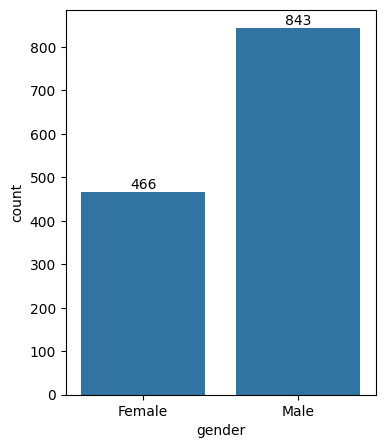

In [71]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='gender')
a.bar_label(a.containers[0])
plt.show()

2. plot the female and male count in each pclass

C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\1398955244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(labels=['p1','p2','p3'])


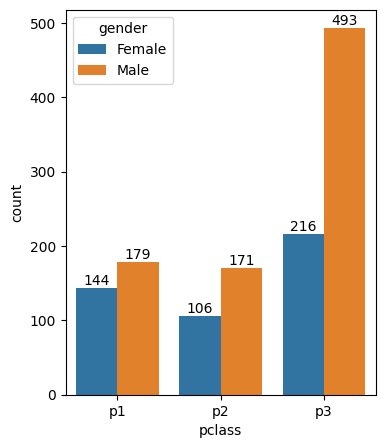

In [72]:
plt.figure(figsize=(4,5))
b=sns.countplot(df,hue='gender',x='pclass')
for i in b.containers:
    b.bar_label(i)

b.set_xticklabels(labels=['p1','p2','p3'])
plt.show()

2. plot the female and male count in each survival_status

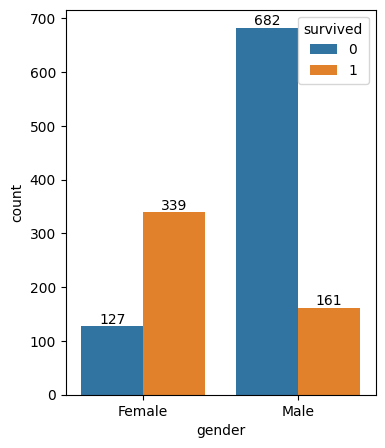

In [73]:
plt.figure(figsize=(4,5))
b=sns.countplot(df,x='gender',hue='survived')
for i in b.containers:
    b.bar_label(i)
plt.show()

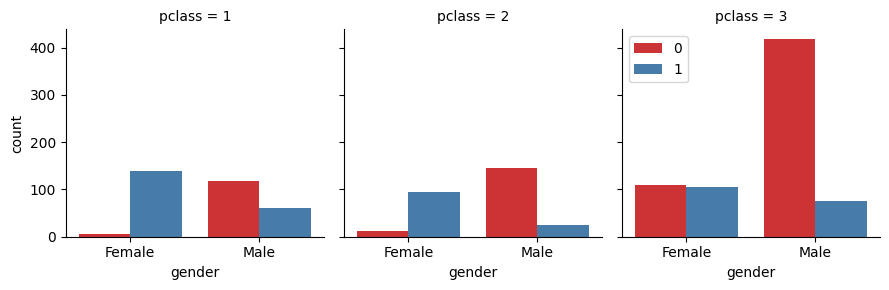

In [74]:
fg=sns.FacetGrid(df,col='pclass')
fg.map_dataframe(sns.countplot,x='gender',hue='survived',hue_order=[0,1],palette='Set1')
plt.legend()

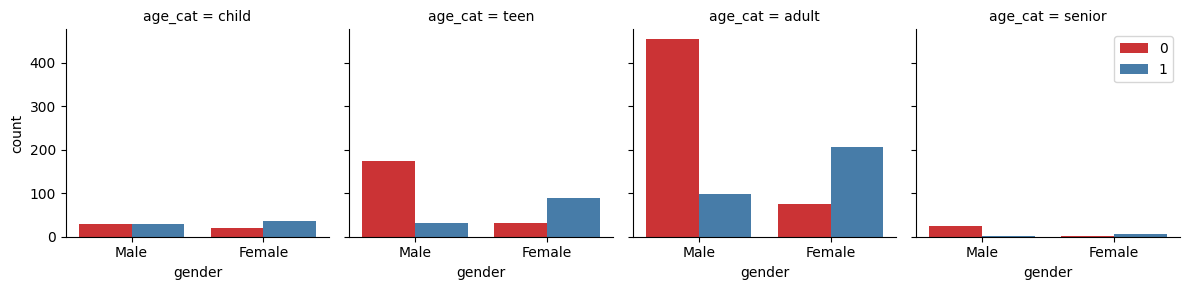

In [75]:
fg=sns.FacetGrid(df,col='age_cat')
fg.map_dataframe(sns.countplot,x='gender',hue='survived',hue_order=[0,1],palette='Set1')
plt.legend()

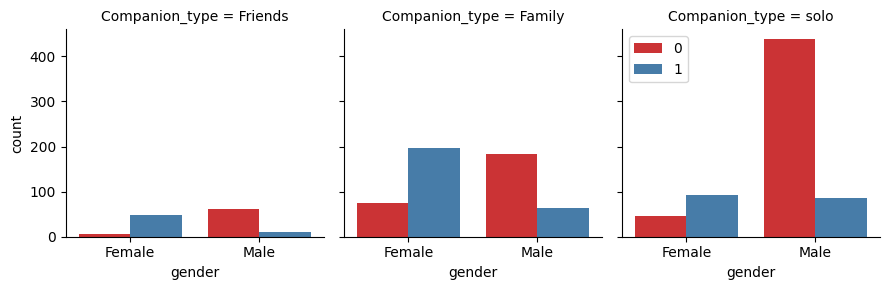

In [76]:
fg=sns.FacetGrid(df,col='Companion_type')
fg.map_dataframe(sns.countplot,x='gender',hue='survived',hue_order=[0,1],palette='Set1')
plt.legend()

<Axes: >

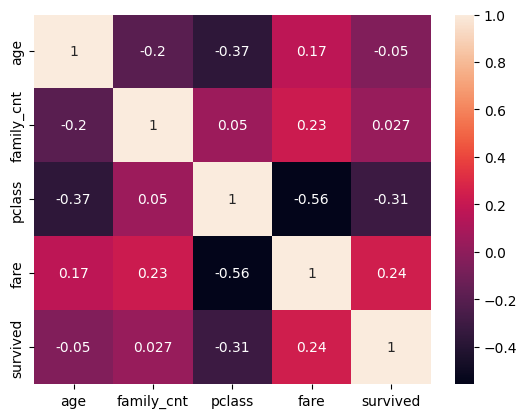

In [77]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='pclass', ylabel='fare'>

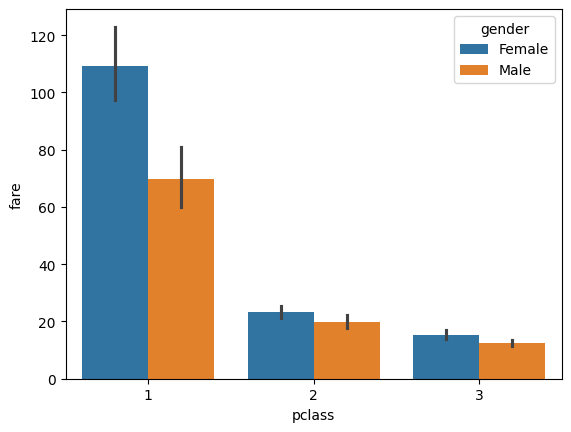

In [78]:
sns.barplot(df,x='pclass',y='fare',hue='gender')

C:\Users\pushp\AppData\Local\Temp\ipykernel_22308\1398955244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(labels=['p1','p2','p3'])


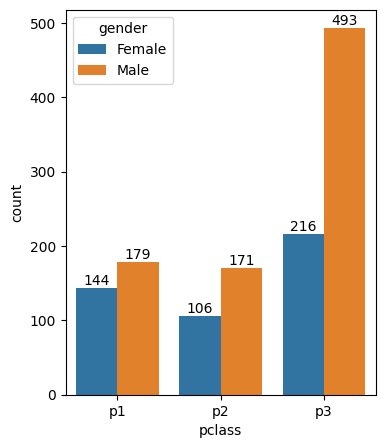

In [79]:
plt.figure(figsize=(4,5))
b=sns.countplot(df,hue='gender',x='pclass')
for i in b.containers:
    b.bar_label(i)

b.set_xticklabels(labels=['p1','p2','p3'])
plt.show()

1. plot the companion_type count

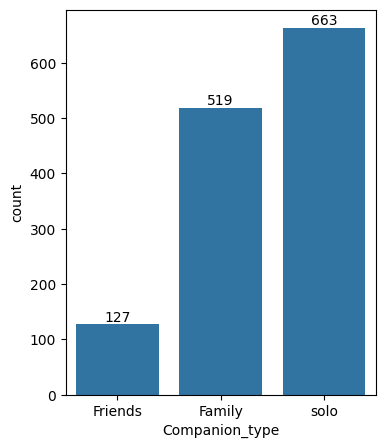

In [80]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type')
a.bar_label(a.containers[0])
plt.show()


1. plot the companion_type count in each gender

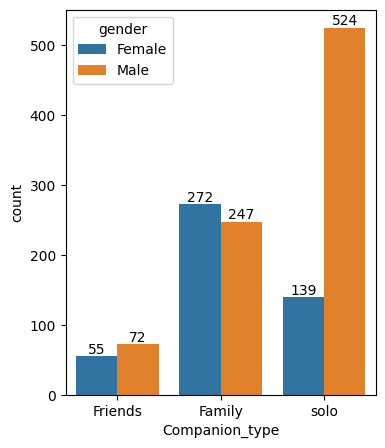

In [81]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='gender')
for i in a.containers:
    a.bar_label(i)
plt.show()

<Axes: xlabel='fare', ylabel='Density'>

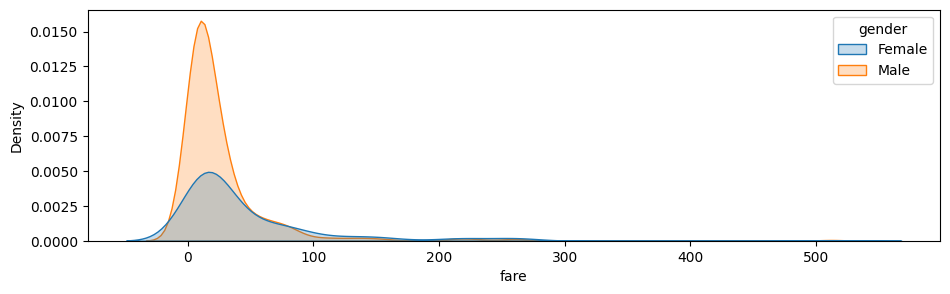

In [82]:
plt.figure(figsize=(11,3))
sns.kdeplot(df,x='fare',hue='gender',fill=True)

<Axes: xlabel='gender', ylabel='fare'>

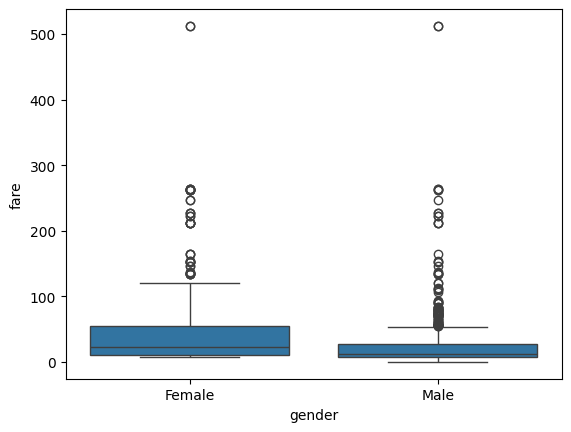

In [83]:
sns.boxplot(df,x='gender',y='fare')

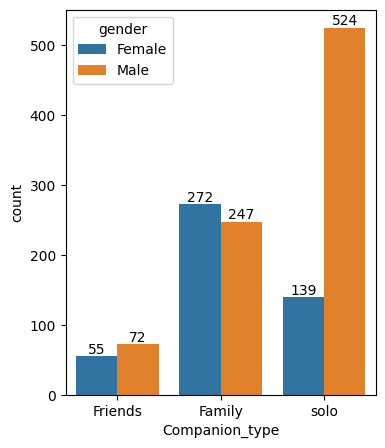

In [84]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='gender')
for i in a.containers:
    a.bar_label(i)
plt.show()

1. plot the companion_type count in each pclass

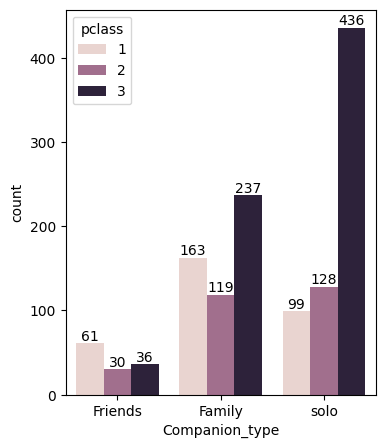

In [85]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='pclass')
for i in a.containers:
    a.bar_label(i)
plt.show()

1. plot the companion_type count in each survival_status

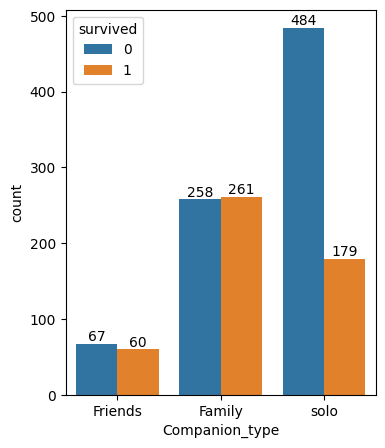

In [86]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='survived')
for i in a.containers:
    a.bar_label(i)
plt.show()

1. plot the age_category count in each gender


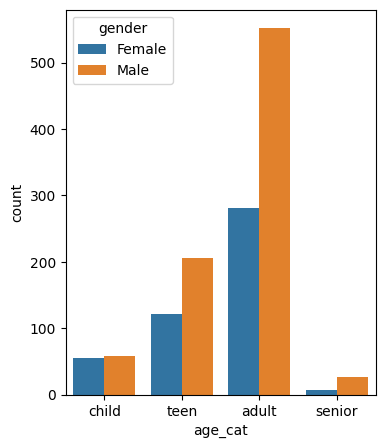

In [87]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='age_cat',hue='gender')
plt.show()


1. plot the age_category count in each pclass

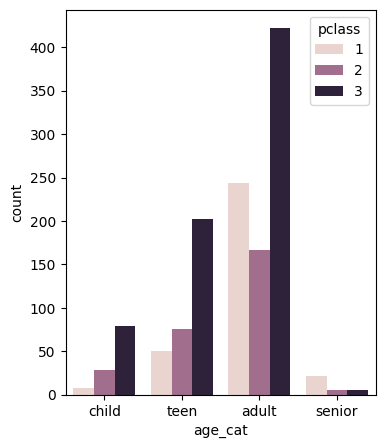

In [88]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='age_cat',hue='pclass')
plt.show()

1. plot the age_category count in each survival_status


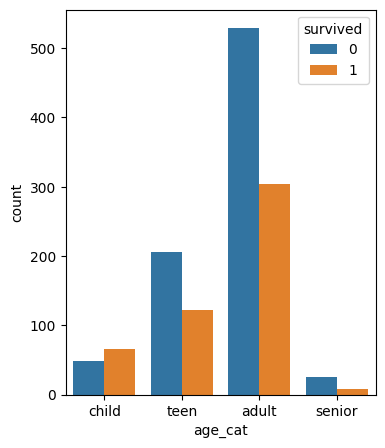

In [89]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='age_cat',hue='survived')
plt.show()

1. plot the embarked count in each gender

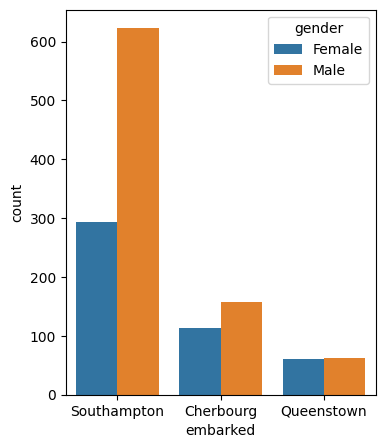

In [90]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='embarked',hue='gender')
plt.show()

1. plot the embarked count in each pclass


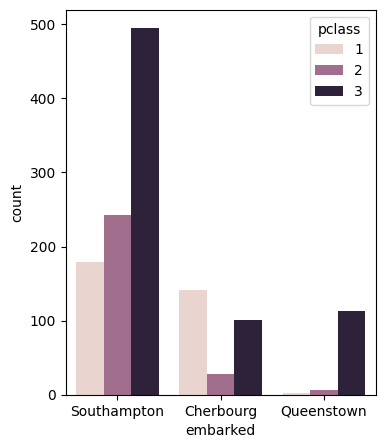

In [91]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='embarked',hue='pclass')
plt.show()

1. plot the embarked count in each survival_status


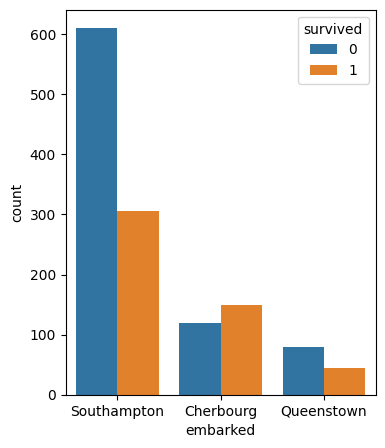

In [92]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='embarked',hue='survived')
plt.show()

2. plot the distribution of fare

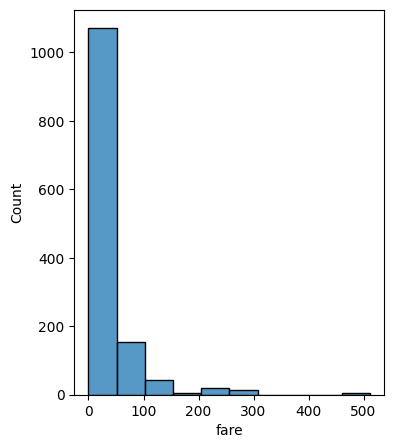

In [93]:
plt.figure(figsize=(4,5))
sns.histplot(df['fare'],bins=10)
plt.show()


3. plot the distribution of age

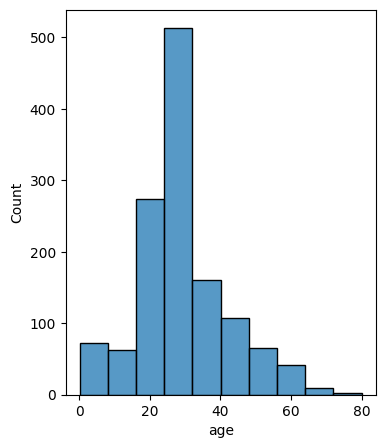

In [94]:
plt.figure(figsize=(4,5))
sns.histplot(df['age'],bins=10)
plt.show()


4. plot the percentage of passengers in each pclass

In [95]:
pclas=df['pclass'].value_counts().sort_index()
pclas



pclass
1    323
2    277
3    709
Name: count, dtype: int64

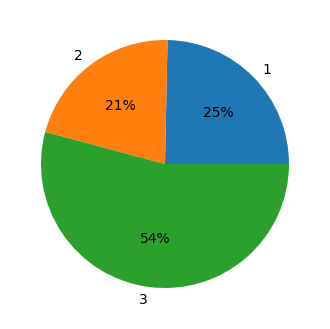

In [96]:
plt.figure(figsize=(4,5))
plt.pie(pclas,labels=pclas.index,autopct='%0.0f%%')
plt.show()

4. plot the percentage of passengers in each age_category

In [97]:
aa=df['age_cat'].value_counts().sort_index()
aa

age_cat
child     115
teen      328
adult     833
senior     33
Name: count, dtype: int64

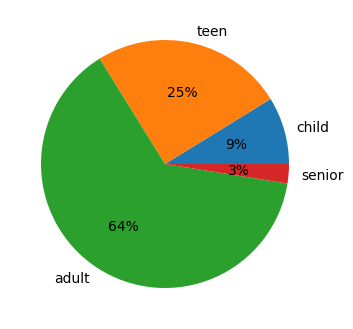

In [98]:
plt.figure(figsize=(4,5))
plt.pie(aa,labels=aa.index,autopct='%0.0f%%')
plt.show()

plot the spread of data in age_column wrt fare_column

<Axes: xlabel='fare', ylabel='age'>

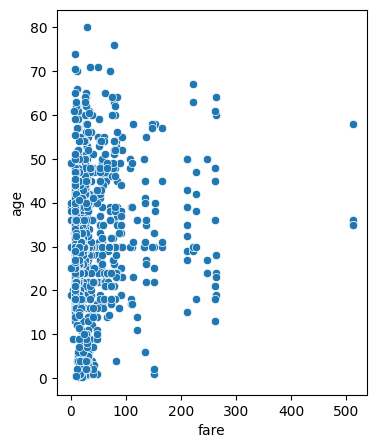

In [99]:
plt.figure(figsize=(4,5))
sns.scatterplot(df,x='fare',y='age')

plot the trend of age wrt fare

<Axes: xlabel='fare', ylabel='age'>

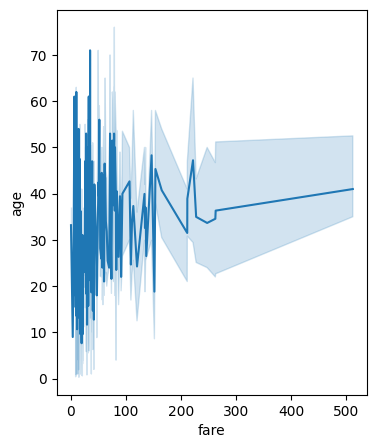

In [100]:
plt.figure(figsize=(4,5))
sns.lineplot(df,x='fare',y='age')

plot the trend of fare wrt pclass

<Axes: xlabel='pclass', ylabel='fare'>

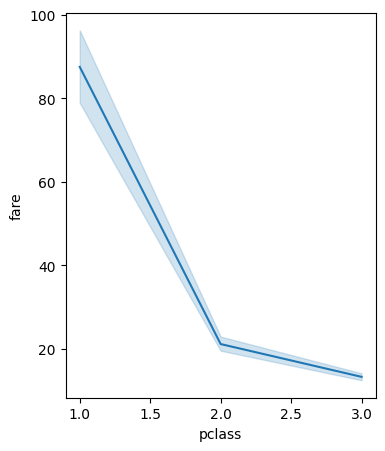

In [101]:
plt.figure(figsize=(4,5))
sns.lineplot(df,x='pclass',y='fare')

find the outlier in fare,age

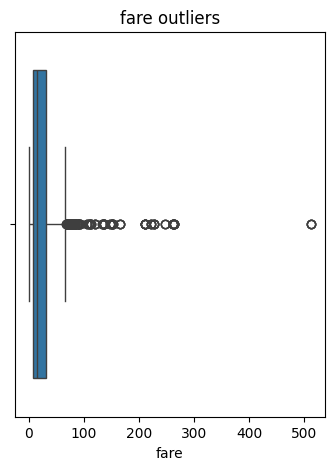

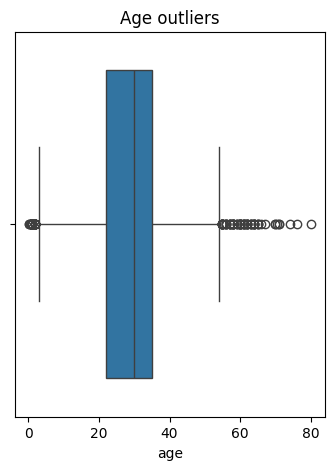

In [102]:
plt.figure(figsize=(4,5))
sns.boxplot(df,x='fare')
plt.title('fare outliers')
plt.show()
plt.figure(figsize=(4,5))
sns.boxplot(df,x='age')
plt.title('Age outliers')
plt.show()

 get the co-relation for all numerical columns using heatmap


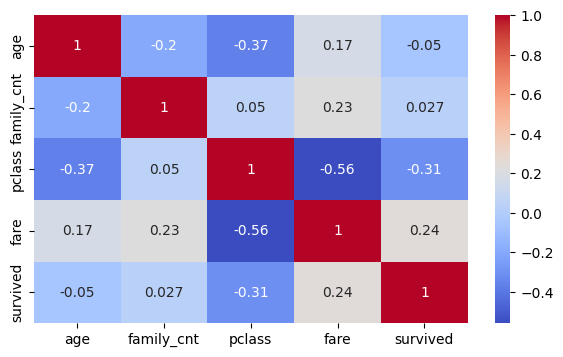

In [103]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(7,4))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

survival_rate of gender in each pclass
avg_age of gender in each pclass
avg_fare of gender in each pclass


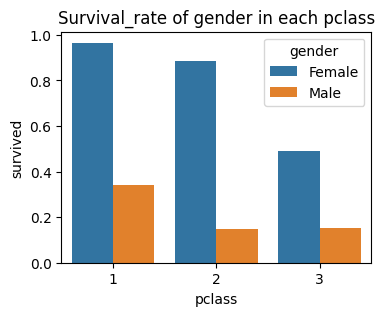

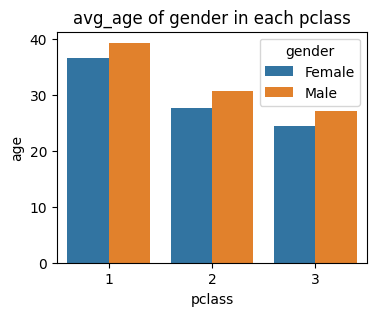

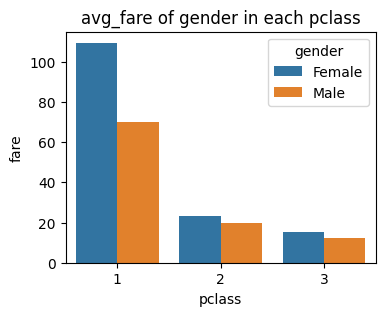

In [104]:
group=df.groupby(['pclass','gender']).agg({'survived':'mean',
                                           'age':'mean',
                                           'fare':'mean'}).reset_index()
plt.figure(figsize=(4,3))
sns.barplot(group,x='pclass',y='survived',hue='gender')
plt.title("Survival_rate of gender in each pclass")
plt.show()


plt.figure(figsize=(4,3))
sns.barplot(group,x='pclass',y='age',hue='gender')
plt.title("avg_age of gender in each pclass")
plt.show()


plt.figure(figsize=(4,3))
sns.barplot(group,x='pclass',y='fare',hue='gender')
plt.title("avg_fare of gender in each pclass")
plt.show()

survival_rate of gender in each age_category
survival_rate of companion_type in each age_category
